<a href="https://colab.research.google.com/github/HeaDShoT4iK/AsilbekKI/blob/main/LAB_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving 9. kc_house_data.csv to 9. kc_house_data.csv
User uploaded file "9. kc_house_data.csv" with length 2515206 bytes


In [2]:
!pip install pandas scikit-learn matplotlib seaborn

In [3]:
import pandas as pd

df = pd.read_csv('9. kc_house_data.csv')
display(df.head())

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
print('Dataset Info:')
df.info()

In [4]:
print('\nMissing Values:')
missing_values = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percent': missing_percent})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))


Missing Values:


,Missing Count,Missing Percent


In [5]:
X = df.drop(['price', 'id', 'date'], axis=1)
Y = df['price']

print("Features (X) shape:", X.shape)
print("Target (Y) shape:", Y.shape)
display(X.head())
display(Y.head())

Features (X) shape: (21613, 20)
Target (Y) shape: (21613,)


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


,price
0,221900.0
1,538000.0
2,180000.0
3,604000.0
4,510000.0


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (17290, 20)
X_test shape: (4323, 20)
Y_train shape: (17290,)
Y_test shape: (4323,)


In [7]:
from sklearn.linear_model import LinearRegression

# Modelni initsializatsiya qilish
linear_model = LinearRegression()

# Modelni o'qitish
linear_model.fit(X_train, Y_train)

print("Linear Regression modeli muvaffaqiyatli o'qitildi.")

ValueError: could not convert string to float: '20140527T000000'

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Test ma'lumotlar to'plamida bashoratlar qilish
Y_pred_linear = linear_model.predict(X_test)

# Modelni baholash metrikalarini hisoblash
mae_linear = mean_absolute_error(Y_test, Y_pred_linear)
mse_linear = mean_squared_error(Y_test, Y_pred_linear)
rmse_linear = mean_squared_error(Y_test, Y_pred_linear, squared=False) # RMSE
r2_linear = r2_score(Y_test, Y_pred_linear)

print("Linear Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"R-squared (R2): {r2_linear:.2f}")

ValueError: could not convert string to float: '20141006T000000'

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Polinom darajasini belgilash
degree = 2

# Polinomial xususiyatlar yaratish va modelni o'qitish uchun pipeline yaratish
polynomial_model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())

# Modelni o'qitish
polynomial_model.fit(X_train, Y_train)

print(f"Polynomial Regression (degree={degree}) modeli muvaffaqiyatli o'qitildi.")

ValueError: could not convert string to float: '20140527T000000'

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

In [ ]:
from sklearn.linear_model import LinearRegression

# Modelni initsializatsiya qilish
linear_model = LinearRegression()

# Modelni o'qitish
linear_model.fit(X_train, Y_train)

print("Linear Regression modeli muvaffaqiyatli o'qitildi.")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Test ma'lumotlar to'plamida bashoratlar qilish
Y_pred_linear = linear_model.predict(X_test)

# Modelni baholash metrikalarini hisoblash
mae_linear = mean_absolute_error(Y_test, Y_pred_linear)
mse_linear = mean_squared_error(Y_test, Y_pred_linear)
rmse_linear = mean_squared_error(Y_test, Y_pred_linear, squared=False) # RMSE
r2_linear = r2_score(Y_test, Y_pred_linear)

print("Linear Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"R-squared (R2): {r2_linear:.2f}")

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Polinom darajasini belgilash
degree = 2

# Polinomial xususiyatlar yaratish va modelni o'qitish uchun pipeline yaratish
polynomial_model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())

# Modelni o'qitish
polynomial_model.fit(X_train, Y_train)

print(f"Polynomial Regression (degree={degree}) modeli muvaffaqiyatli o'qitildi.")

ValueError: could not convert string to float: '20140527T000000'

In [13]:
X = df.drop(['price', 'id', 'date'], axis=1)
Y = df['price']

print("Features (X) shape:", X.shape)
print("Target (Y) shape:", Y.shape)
display(X.head())
display(Y.head())

Features (X) shape: (21613, 18)
Target (Y) shape: (21613,)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


,price
0,221900.0
1,538000.0
2,180000.0
3,604000.0
4,510000.0


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (17290, 18)
X_test shape: (4323, 18)
Y_train shape: (17290,)
Y_test shape: (4323,)


In [15]:
from sklearn.linear_model import LinearRegression

# Modelni initsializatsiya qilish
linear_model = LinearRegression()

# Modelni o'qitish
linear_model.fit(X_train, Y_train)

print("Linear Regression modeli muvaffaqiyatli o'qitildi.")

Linear Regression modeli muvaffaqiyatli o'qitildi.


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Test ma'lumotlar to'plamida bashoratlar qilish
Y_pred_polynomial = polynomial_model.predict(X_test)

# Modelni baholash metrikalarini hisoblash
mae_polynomial = mean_absolute_error(Y_test, Y_pred_polynomial)
mse_polynomial = mean_squared_error(Y_test, Y_pred_polynomial)
rmse_polynomial = np.sqrt(mse_polynomial) # RMSE ni qo'lda hisoblash
r2_polynomial = r2_score(Y_test, Y_pred_polynomial)

print(f"Polynomial Regression (degree={degree}) Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_polynomial:.2f}")
print(f"Mean Squared Error (MSE): {mse_polynomial:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_polynomial:.2f}")
print(f"R-squared (R2): {r2_polynomial:.2f}")

TypeError: got an unexpected keyword argument 'squared'

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Test ma'lumotlar to'plamida bashoratlar qilish
Y_pred_linear = linear_model.predict(X_test)

# Modelni baholash metrikalarini hisoblash
mae_linear = mean_absolute_error(Y_test, Y_pred_linear)
mse_linear = mean_squared_error(Y_test, Y_pred_linear)
rmse_linear = np.sqrt(mse_linear) # RMSE ni qo'lda hisoblash
r2_linear = r2_score(Y_test, Y_pred_linear)

print("Linear Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"R-squared (R2): {r2_linear:.2f}")

Linear Regression Model Performance:
Mean Absolute Error (MAE): 127493.34
Mean Squared Error (MSE): 45173046132.79
Root Mean Squared Error (RMSE): 212539.52
R-squared (R2): 0.70


In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Polinom darajasini belgilash
degree = 2

# Polinomial xususiyatlar yaratish va modelni o'qitish uchun pipeline yaratish
polynomial_model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())

# Modelni o'qitish
polynomial_model.fit(X_train, Y_train)

print(f"Polynomial Regression (degree={degree}) modeli muvaffaqiyatli o'qitildi.")

Polynomial Regression (degree=2) modeli muvaffaqiyatli o'qitildi.


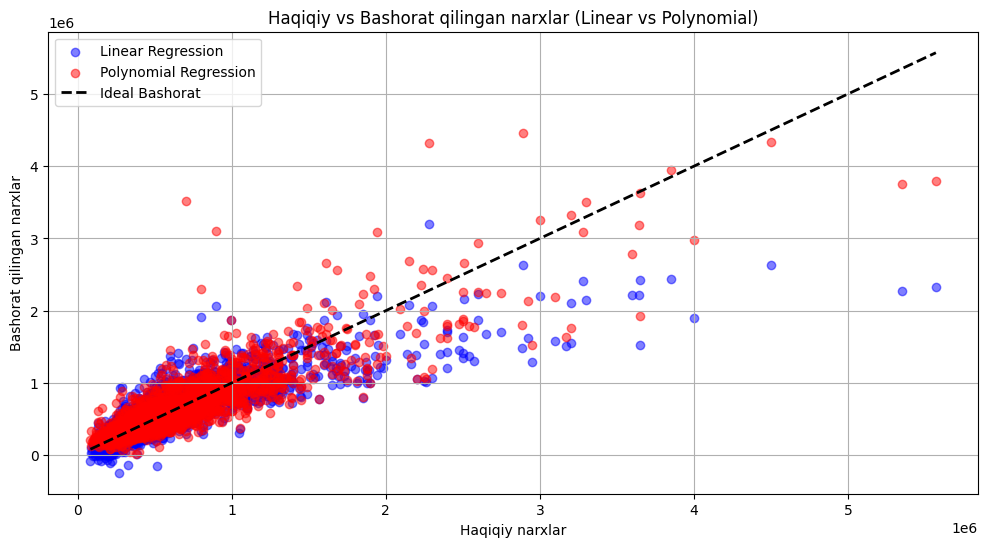

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Haqiqiy qiymatlar va bashoratlar o'rtasidagi bog'liqlik
plt.scatter(Y_test, Y_pred_linear, color='blue', alpha=0.5, label='Linear Regression')
plt.scatter(Y_test, Y_pred_polynomial, color='red', alpha=0.5, label='Polynomial Regression')

# Ideal chiziq (Haqiqiy = Bashorat)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2, label='Ideal Bashorat')

plt.xlabel('Haqiqiy narxlar')
plt.ylabel('Bashorat qilingan narxlar')
plt.title('Haqiqiy vs Bashorat qilingan narxlar (Linear vs Polynomial)')
plt.legend()
plt.grid(True)
plt.show()